# 01 - Analyse exploratoire de Boston Housing

Objectif : controler la qualite du fichier source et comprendre les variables avant la modelisation.

## Prerequis

Executer `pip install -r requirements.txt` depuis la racine du projet. Le notebook utilise exclusivement le fichier local `data/raw/BostonHousing.csv`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
# Fonctionne depuis la racine ou depuis le dossier notebooks/
candidates = [
    Path.cwd() / "data" / "raw" / "BostonHousing.csv",
    Path.cwd().parent / "data" / "raw" / "BostonHousing.csv",
]
data_path = next((path for path in candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("BostonHousing.csv introuvable dans data/raw/")

df = pd.read_csv(data_path)
print(f"Source : {data_path.resolve()}")
print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")
df.head()

Source : C:\Users\pc\openhousing-mlops\data\raw\BostonHousing.csv
Dimensions : 506 lignes x 14 colonnes


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## Structure et qualite des donnees

In [3]:
print("Colonnes :")
print(df.columns.tolist())
print()
df.info()

Colonnes :
['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [4]:
quality = pd.DataFrame({
    "type": df.dtypes.astype(str),
    "valeurs_manquantes": df.isna().sum(),
    "taux_manquant_pct": (df.isna().mean() * 100).round(2),
    "valeurs_uniques": df.nunique(),
})
print(f"Doublons : {df.duplicated().sum()}")
display(quality)

Doublons : 0


,type,valeurs_manquantes,taux_manquant_pct,valeurs_uniques
crim,float64,0,0.0,504
zn,float64,0,0.0,26
indus,float64,0,0.0,76
chas,int64,0,0.0,2
nox,float64,0,0.0,81
rm,float64,0,0.0,446
age,float64,0,0.0,356
dis,float64,0,0.0,412
rad,int64,0,0.0,9
tax,int64,0,0.0,66


In [5]:
# Statistiques descriptives
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
crim,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
zn,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
indus,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
chas,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
nox,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
rm,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
age,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
dis,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
rad,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
tax,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


## Visualisations

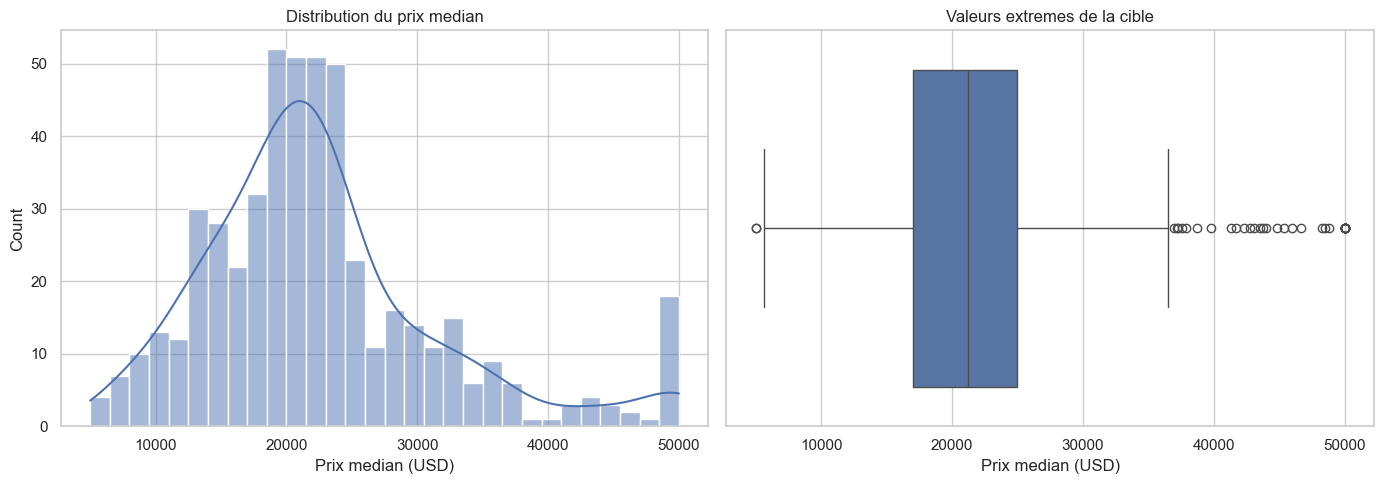

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["medv"] * 1_000, bins=30, kde=True, ax=axes[0])
axes[0].set(title="Distribution du prix median", xlabel="Prix median (USD)")
sns.boxplot(x=df["medv"] * 1_000, ax=axes[1])
axes[1].set(title="Valeurs extremes de la cible", xlabel="Prix median (USD)")
plt.tight_layout()
plt.show()

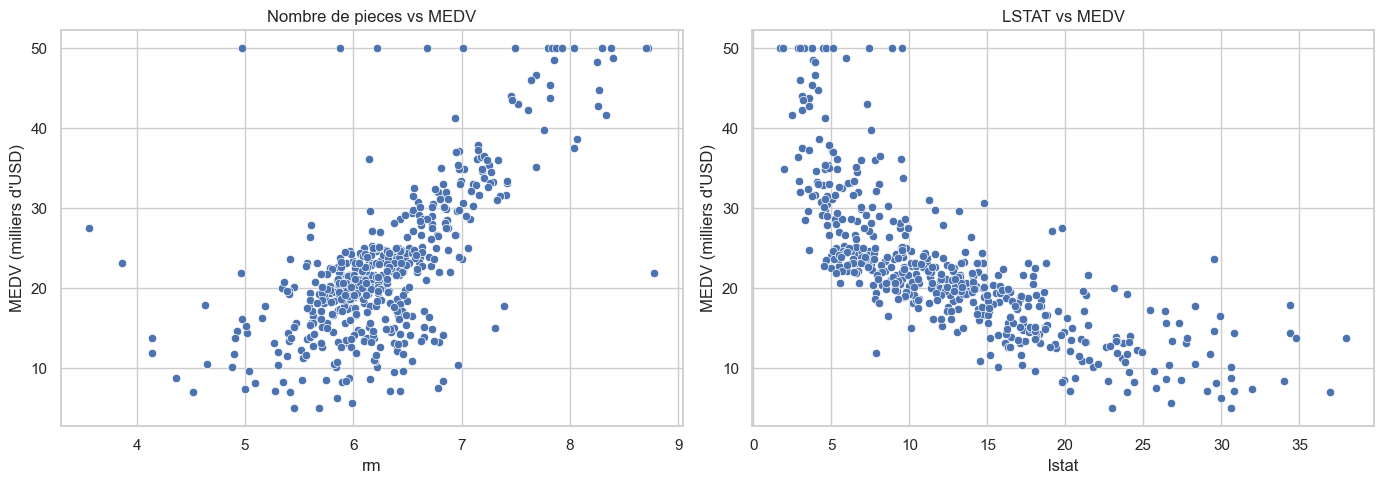

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x="rm", y="medv", ax=axes[0])
axes[0].set(title="Nombre de pieces vs MEDV", ylabel="MEDV (milliers d'USD)")
sns.scatterplot(data=df, x="lstat", y="medv", ax=axes[1])
axes[1].set(title="LSTAT vs MEDV", ylabel="MEDV (milliers d'USD)")
plt.tight_layout()
plt.show()

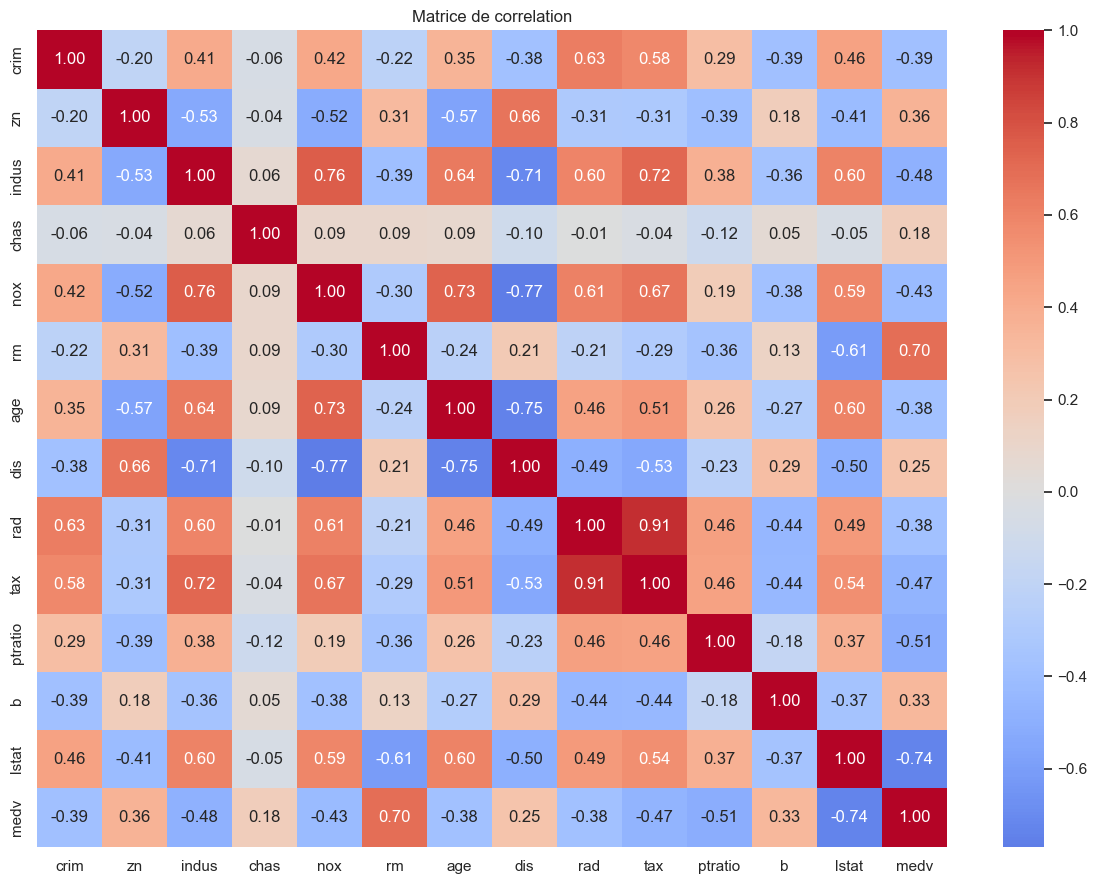

,correlation_avec_medv
medv,1.000000
rm,0.695360
zn,0.360445
b,0.333461
dis,0.249929
chas,0.175260
age,-0.376955
rad,-0.381626
crim,-0.388305
nox,-0.427321


In [8]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Matrice de correlation")
plt.tight_layout()
plt.show()

display(corr["medv"].sort_values(ascending=False).to_frame("correlation_avec_medv"))

## Top 10 correlations avec MEDV

Ce graphique complete la matrice en mettant en evidence les relations lineaires les plus fortes avec la cible.

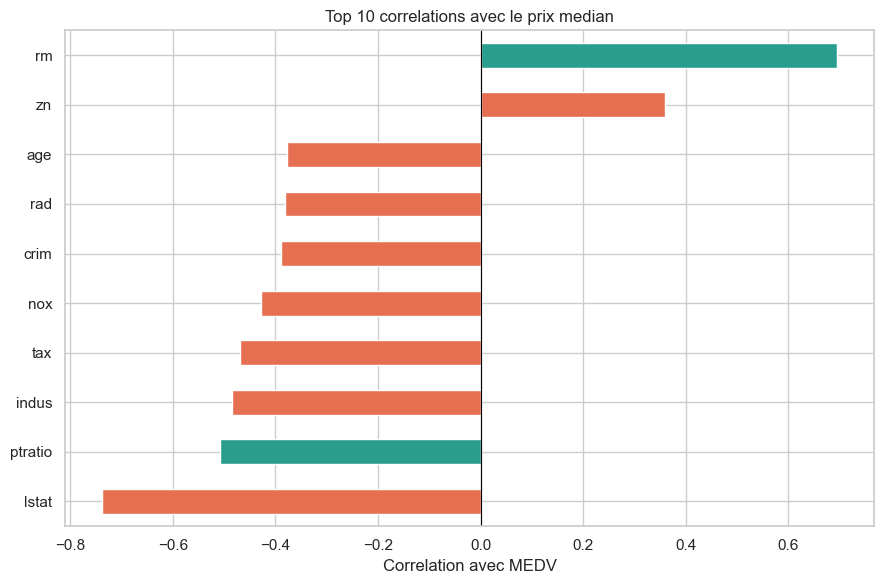

,correlation_avec_medv
lstat,-0.737663
rm,0.695360
ptratio,-0.507787
indus,-0.483725
tax,-0.468536
nox,-0.427321
crim,-0.388305
rad,-0.381626
age,-0.376955
zn,0.360445


In [9]:
target_corr = (
    df.corr(numeric_only=True)["medv"]
    .drop("medv")
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 6))
colors = ["#2a9d8f" if value > 0 else "#e76f51" for value in target_corr.values]
target_corr.sort_values().plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Correlation avec MEDV")
plt.title("Top 10 correlations avec le prix median")
plt.tight_layout()
plt.show()

display(target_corr.to_frame("correlation_avec_medv"))

## Conclusion EDA

- La cible `medv` est exprimee en milliers de dollars dans la source.
- La modelisation la convertira en USD.
- La variable historique `b`, liee a la composition raciale des quartiers, sera exclue du modele pour des raisons ethiques.
- Les eventuelles valeurs manquantes seront traitees dans les pipelines de modelisation.